# Interpolação Numérica

---

**Como entregar:** Enviar o seu jupyter notebook (.ipynb) pelo próprio Classroom. Uma cópia deste será automaticamente criada para você no seu Google Drive, você pode usar essa cópia mesmo, sem necessidade de criar outra.


**Leia com atenção:**


*   Você deve fazer obrigatoriamente todas as atividades marcadas com a exclamação❗.
*   Atividades marcadas com 🧩 são opcionais.
*   Use o Google Colab para executar o notebook e fazer a tarefa, ou baixe no seu computador e faça na API que preferir, mas lembre-se de entregar no Classroom a versão final.
*   A atividade vai ser baseada no seu número USP.
*   Há questões dissertativas!
*   Siga o passo a passo indicado no tutorial, respondendo as perguntas das atividades propostas no seu jupyter notebook.
*   O notebook que entregar deve estar 100% funcional, isto é, todos os códigos rodando no Colab sem erros.
*   Entregue o notebook completo, com todo conteúdo original e mais os seus códigos e textos.
*   Esta tarefa é individual e haverá controle de similaridade. Tentativas de cópias, fraude, compra-venda de EPs não serão toleradas, levando a nota zero na tarefa e posterior análise para medidas cabíveis.
*   O uso de IA é permitido, mas não para respostas completas, e sim auxílio no entendimento. **Caso use IA, você deve comentar que usou**. Note que há questões dissertativas e justificativas devem ser dadas.
*   ❗Exercício 00:❗ Para mostrar que você leu até aqui, escreva seu nome completo (assinatura) na linha a seguir:




*Assinatura:*



---



## Preliminares

In [ ]:
import numpy as np         #Numpy
import matplotlib.pyplot as plt # Gráficos

#### ❗Exercício 0❗

Preencha o seu número USP abaixo

In [ ]:
# Coloque aqui o seu número USP
nusp = 12553733

nusp_str=str(nusp).replace("0","")

magic_ilong = int(nusp_str)
magic_int = int(str(magic_ilong)[-1:])
#magic_int = int(list(set(nusp_str))[0])

print("magic_ilong  =", magic_ilong)
print("magic_int =", magic_int)

magic_ilong  = 12553733
magic_int = 3


## Teoria de Interpolação

Considere a tabela
$$
    \begin{array}{c|cccc}
        x & x_0 & x_1 & \dots & x_n \\
        \hline
        y & y_0 & y_1 & \dots & y_n
    \end{array} ,
$$

com $x_i \ne x_j$ se $i \ne j$.
Então, o polinômio interpolador $p_n$ da tabela na forma de Lagrange é dado por

$$
    p_n(x) = \sum_{j=0}^n y_j L_j(x)
$$

onde os polinômios de Lagrange $L_j$ são definidos por

$$
    L_j(x) = \prod^n_{\substack{k = 0 \\ k \ne j}} \frac{x - x_k}{x_j - x_k}, \quad 0 \le j \le n.
$$



**Exemplo**

Considere a tabela

$$
    \begin{array}{c|rccc}
        x & -1 & 0 & 1 & 2 \\
        \hline
        2^x & 0.5 & 1 & 2 & 4
    \end{array}
$$

da função $2^x$ nos pontos $-1, 0, 1$ e $2$.

Vamos encontrar o polinômio de grau 3 que interpola esses pontos, passo a passo!


In [ ]:
# Nossa tabela

a = -1  #inicio
b = 2   #fim
n = 3   #grau (são n+1 pontos)

#Valores de x uniformemente espaçados
xd = np.linspace(a, b, n+1)
print("x:", xd)

# A função que queremos interpolar
def f(x):
  return np.power(2.0, x)

#Valores de 2^x nos pontos de interpolação
yd = f(xd)
print("y:", yd)


x: [-1.  0.  1.  2.]
y: [0.5 1.  2.  4. ]


Agora vamos ver quem são os nossos polinômios de Lagrange, os $L_i(x)$.

In [ ]:
#Polinômio de Lagrange
def L(x, i, xd):
  xi = xd[i]
  x_sem_i = np.delete(xd, [i])
  numer = x - x_sem_i
  denom = xi - x_sem_i
  return np.prod(numer/denom)


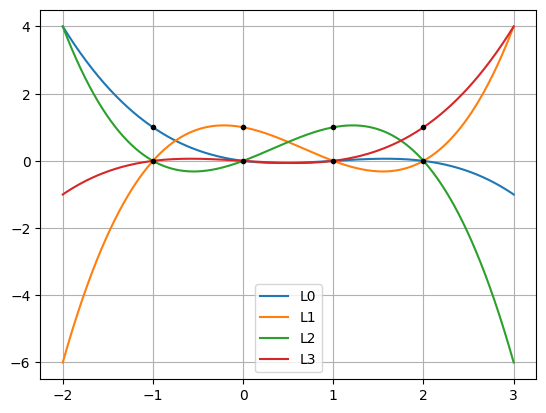

In [ ]:
#Vamos avaliar esses polinômios L_i em muitos pontos e fazer um gráfico deles
N = 1000
x = np.linspace(a-1, b+1, N+1)

L0=np.empty(N+1)
L1=np.empty(N+1)
L2=np.empty(N+1)
L3=np.empty(N+1)

for j, xj in enumerate(x):
  L0[j] = L(xj, 0, xd)
  L1[j] = L(xj, 1, xd)
  L2[j] = L(xj, 2, xd)
  L3[j] = L(xj, 3, xd)

plt.plot(x, L0, label="L0")
plt.plot(x, L1, label="L1")
plt.plot(x, L2, label="L2")
plt.plot(x, L3, label="L3")
plt.plot(xd, np.ones(len(xd)), 'k.', xd, np.zeros(len(xd)), 'k.')
plt.grid()
plt.legend()
plt.show()

Observe como cada um dos $L_i$ é um polinômio de grau $n$ ($n=3$ neste caso), que vale 1 no ponto $x_i$ e zero nos outros pontos $x_j$, com $j\neq i$.

In [ ]:
# O polinômio interpolador de Lagrange é combinação linear dos Li
def pol(x, xd, yd):
  pol = 0.0
  for i in range(len(xd)):
    pol = pol + L(x, i, xd)* yd[i]
  return pol

Vamos calcular $\sqrt{2} = 2^{0.5}$ com esse polinômio:

In [ ]:
raiz2_aprox = pol(0.5, xd, yd)
raiz2_np = np.sqrt(2.0)
print("Raiz de 2 aproximada : " , raiz2_aprox)
print("Raiz de 2 do numpy : " , raiz2_np)
print("Erro:", raiz2_aprox - raiz2_np )

Raiz de 2 aproximada :  1.40625
Raiz de 2 do numpy :  1.4142135623730951
Erro: -0.007963562373095145


Agora vamos avaliar o polinômio em um conjunto grande de pontos, para ver como o polinômio aproxima a função.

Vamos definir tudo novamente em uma única célula para facilitar:

x: [-1.  0.  1.  2.]
y: [0.5 1.  2.  4. ]
Função e polinômio interpolador:


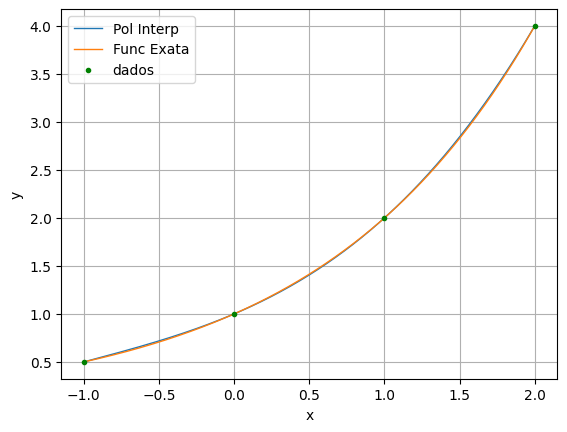

Erro:


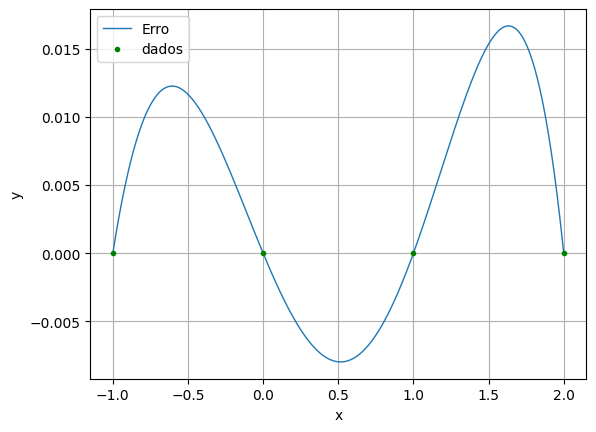

Erro máximo =  0.01665792490057605


In [ ]:

# Nossa tabela
a = -1  #inicio
b = 2   #fim
n = 3   #grau (são n+1 pontos)

#Valores de x uniformemente espaçados
xd = np.linspace(a, b, n+1)
print("x:", xd)

# A função que queremos interpolar
def f(x):
  return np.power(2.0, x)

#Valores de 2^x nos pontos de interpolação
yd = f(xd)
print("y:", yd)

#Pontos de testagem
N = 1000
x = np.linspace(a, b, N+1)

#Função exata
y_real= f(x)

#Avalio o polinomio em cada um desses pontos
poln=np.empty(N+1)
for j, xj in enumerate(x):
  poln[j] = pol(xj, xd, yd)

#Gráficos
print("Função e polinômio interpolador:")
plt.plot(x, poln, label="Pol Interp", linewidth=1)
plt.plot(x, y_real, label="Func Exata",linewidth=1)
plt.plot(xd, yd, 'g.', label="dados")
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
plt.legend()
plt.show()

print("Erro:")
plt.plot(x, poln-y_real, label="Erro", linewidth=1)
plt.plot(xd, np.zeros(len(xd)), 'g.', label="dados")
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
plt.legend()
plt.show()

print("Erro máximo = ", np.max(np.abs(poln-y_real)) )

A aproximação parece ser excelente! Isso usando apenas 4 pontos (polinômio de grau 3)! O que acontece se aumentar o grau do polinômio?

In [ ]:
a = -1  #inicio
b = 2   #fim

def f(x):
  return np.power(2.0, x)

#Pontos de testagem
N = 1000
x = np.linspace(a, b, N+1)
#Função exata
y_real = f(x)

#Varrer diferentes graus
nmax = 20
print("|    n | erro     ")
for n in range(1, nmax):
  xd = np.linspace(a, b, n+1) #x tabelado
  yd = f(xd)                  #y tabelado
  poln=np.empty(N+1) #Avalio o polinomio nos pontos
  for j, xj in enumerate(x):
    poln[j] = pol(xj, xd, yd)

  erro_La = np.max(np.abs(poln-y_real))
  print(f"| {n:4} | {erro_La:0.8} ")



|    n | erro     
|    1 | 0.85987409 
|    2 | 0.12611564 
|    3 | 0.016657925 
|    4 | 0.0019482528 
|    5 | 0.00020186097 
|    6 | 1.8659782e-05 
|    7 | 1.5519952e-06 
|    8 | 1.1710346e-07 
|    9 | 8.0767544e-09 
|   10 | 5.1256155e-10 
|   11 | 3.0115022e-11 
|   12 | 1.6537882e-12 
|   13 | 1.1723955e-13 
|   14 | 1.2523316e-13 
|   15 | 1.7674751e-13 
|   16 | 2.3314684e-13 
|   17 | 5.9396932e-13 
|   18 | 8.7174712e-13 
|   19 | 2.4487079e-12 




---

Vimos em sala que uma outra opção de construir um polinômio interpolador é usando diferenças dividias e o **interpolador na forma de Newton**:

$$
    p_n(x) = f_0 + f_{01}(x-x_0) + f_{012}(x-x_0)(x-x_1) + ... + f_{012...n}(x-x_0)(x-x_1)...(x-x_{n-1})
$$

onde as diferenças divididas, que aqui foram apresentadas com notação reduzida, podem ser expressadas como
$$
f_{012...n} = f[x_0, x_1, ..., x_n] = \frac{f[x_1, ..., x_n]-f[x_0, x_1, ..., x_{n-1}]}{x_n-x_0},
$$
que pode ser usada recursivamente até chegarmos a um único ponto, onde temos
$$
f_{j} = f[x_j] = f(x_j) = y_j
$$




### ❗Exercício 1 ❗

**Tarefa:** Implemente uma função que calcula o polinômio interpolador usando a forma de Newton. (Dica: primeiro implemente uma função que calcula diferenças divididas).


Considere a função
$$
    f(x) = 2^x,\quad x \in [-1, 2].
$$
e os pontos uniformemente espaçados em $n$ intervalos ($n+1$ pontos), onde $n$ é o último dígito não nulo do seu número USP ($n=$ magic_int).

1.  Construa o polinômio interpolador dessa função nesses pontos usando o seu método de interpolação e compare com o método de Lagrange implementado anteriormente. Eles devem coincidir a menos de erros de arredondamento.
2.  Avalie esse polinômio em $N=1000$ pontos e faça um gráfico da aproximação e um do erro.
3. (Teórico) Usando o teorema do erro de interpolação discutido em aula (ver fórmula a baixo), estime qual o número de pontos seria necessário para obter um erro máximo menor que $10^{-5}$.
4.  Varie o valor de $n$ e verifique se o erro cai quando aumentamos o grau do polinômio, usando a sua implmentação de interpolação por Newton. Faça uma tabela do erro em função de $n$, como feito para o método de Lagrange, mas agora com a sua implementação.


Fórmula do erro de interpolação em um intervalo $[a,b]$ com $n+1$ pontos de interpolação:

$$
E_n(x)=|f(x)-p_n(x)| \leq \frac{\max_{[a,b]}\{|f^{(n+1)}(y)|\}}{(n+1)!}(b-a)^{n+1}
$$


|    n | erro     
|    1 | 0.85987409 
|    2 | 0.12611564 
|    3 | 0.01665792 
|    4 | 0.00194825 
|    5 | 0.00020186 
|    6 | 0.00001866 
|    7 | 0.00000155 
|    8 | 0.00000012 
|    9 | 0.00000001 
|   10 | 0.00000000 
|   11 | 0.00000000 
|   12 | 0.00000000 
|   13 | 0.00000000 
|   14 | 0.00000000 
|   15 | 0.00000000 
|   16 | 0.00000000 
|   17 | 0.00000000 
|   18 | 0.00000000 
|   19 | 0.00000000 
|   20 | 0.00000000 


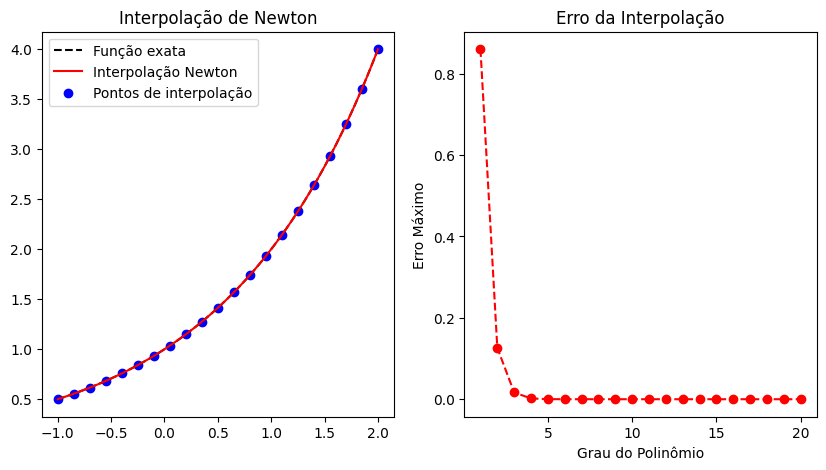

In [ ]:


# Intervalo
a, b = -1, 2

# Função que queremos interpolar
def f(x):
    return np.power(2.0, x)

# Função para calcular a tabela de diferenças divididas
def calc_dif_div(xd, yd):
    n = len(xd)
    tabela = np.zeros((n, n))
    tabela[:, 0] = yd  # Primeira coluna são os valores de f(x)

    for j in range(1, n):
        for i in range(n - j):
            tabela[i, j] = (tabela[i+1, j-1] - tabela[i, j-1]) / (xd[i+j] - xd[i])

    return tabela[0]  # Retorna a primeira linha da tabela (os coeficientes)

# Função para avaliar o polinômio interpolador de Newton
def newton_interpolador(xd, coef, x):
    n = len(xd)
    resultado = coef[0]
    produto = 1
    for i in range(1, n):
        produto *= (x - xd[i-1])
        resultado += coef[i] * produto
    return resultado


# Pontos para avaliar a interpolação
N = 1000
x = np.linspace(a, b, N+1)
y_real = f(x)

# Testar diferentes graus
nmax = 20
erros = []

print("|    n | erro     ")
for n in range(1, nmax + 1):
    xd = np.linspace(a, b, n+1)  # Pontos de interpolação
    yd = f(xd)

    # Calcular os coeficientes das diferenças divididas
    f0n = calc_dif_div(xd, yd)

    # Avaliar o polinômio nos pontos de teste
    poln = np.array([newton_interpolador(xd, f0n, xj) for xj in x])

    # Calcular o erro máximo
    erro = np.max(np.abs(poln - y_real))
    erros.append(erro)

    print(f"| {n:4} | {erro:.8f} ")

# Plotar o polinômio interpolador e o erro
plt.figure(figsize=(10, 5))

# Gráfico do polinômio interpolador
plt.subplot(1, 2, 1)
plt.plot(x, y_real, label="Função exata", color="black", linestyle="dashed")
plt.plot(x, poln, label="Interpolação Newton", color="red")
plt.scatter(xd, yd, color="blue", label="Pontos de interpolação")
plt.legend()
plt.title("Interpolação de Newton")

# Gráfico do erro
plt.subplot(1, 2, 2)
plt.plot(range(1, nmax + 1), erros, marker="o", linestyle="dashed", color="red")
plt.xlabel("Grau do Polinômio")
plt.ylabel("Erro Máximo")
plt.title("Erro da Interpolação")

plt.show()

Comentários e deduções teóricas:

In [ ]:
# Escolher o grau máximo usado na interpolação
n = magic_int  # Pega o maior grau testado
xd = np.linspace(a, b, n+1)  # Pontos de interpolação
yd = f(xd)

# Calcular os coeficientes das diferenças divididas
f0n = calc_dif_div(xd, yd)

# Avaliar o polinômio interpolador em x = 0.5
x_teste = 0.5
resultado = newton_interpolador(xd, f0n, x_teste)

# Comparar com o valor exato
valor_exato = f(x_teste)
erro = abs(resultado - valor_exato)

# Exibir os resultados
print(f"\nTestando em x = {x_teste}")
print(f"Valor interpolado: {resultado:.8f}")
print("Raiz de 2 aproximada Langrange: " , raiz2_aprox)
print(f"Valor exato: {valor_exato:.8f}")
print(f"Erro absoluto: {erro:.8e}")


Testando em x = 0.5
Valor interpolado: 1.40625000
Raiz de 2 aproximada Langrange:  1.40625
Valor exato: 1.41421356
Erro absoluto: 7.96356237e-03


In [ ]:
import scipy.misc as sp
import math

def erro_teorico(f, a, b, n):
    # Derivada de ordem (n+1)
    def derivada_ordem_n_mais_1(x):
        return sp.derivative(f, x, dx=1e-5, n=n+1, order=2*(n+1)+1)

    # Encontrar o máximo de |f^(n+1)(y)| no intervalo [a, b]
    pontos_teste = np.linspace(a, b, 1000)  # Discretiza o intervalo
    valores_derivada = np.abs([derivada_ordem_n_mais_1(x) for x in pontos_teste])
    max_derivada = np.max(valores_derivada)

    # Aplicar a fórmula do erro teórico
    erro = (max_derivada / math.factorial(n+1)) * (b - a) ** (n+1)

    return erro

como n = 3 fazendo a quarta derivada da função 2^x chegamos em 2^x*(ln2)^4, sendo assim o valor máximo se da quando x =2, então teremos o erro como 4*(ln2)^4*(2-(-1))^4 /(4!) e genericamente ficaria 4*(ln2)^n*(3)^(n+1)/(n+1)!



In [ ]:
import numpy as np
import math
def erroMax(n):
  return 4*(((np.log(2))**n)*((3)**(n+1)))/(math.factorial(n+1))
termina =0;
for i in range(20):
  if(erroMax(i)<0.00001):
    print("i minimo = ", i)
    break;



i minimo =  13


Sim colocando valores maiores de n o erro diminui bastante



---



### ❗Exercício 2 ❗



Considere a função
$$
    f(x) = \frac{1}{1 + x^2},\quad x \in [-5, 5].
$$
conhecida como **Função de Runge**, e os pontos uniformemente espaçados em $n$ intervalos, onde $n$ é o último dígito não nulo do seu número USP ($n=$ magic_int). Ou seja,
$$
x_i = 10i/n-5, \quad, i=0,1,...,n
$$


1.  Construa o polinômio interpolador dessa função nesses pontos.
2.  Avalie esse polinômio em $N=1000$ pontos e faça um gráfico da aproximação e do erro.
3.  Calcule o erro máximo
4.  Varie o valor de $n$ e verifique se o erro cai quando aumentamos o grau do polinômio. Faça uma tabela do erro em função de $n$.


|    n | erro     
|    1 | 0.96153846 
|    2 | 0.64622664 
|    3 | 0.70701357 
|    4 | 0.43835262 
|    5 | 0.43269231 
|    6 | 0.61691949 
|    7 | 0.24735861 
|    8 | 1.04517391 
|    9 | 0.30028113 
|   10 | 1.91564305 
|   11 | 0.55673649 
|   12 | 3.66299679 
|   13 | 1.07004059 
|   14 | 7.19211304 
|   15 | 2.10680042 
|   16 | 14.38626844 
|   17 | 4.22345252 
|   18 | 29.18564868 
|   19 | 8.57563265 
|   20 | 59.76832784 


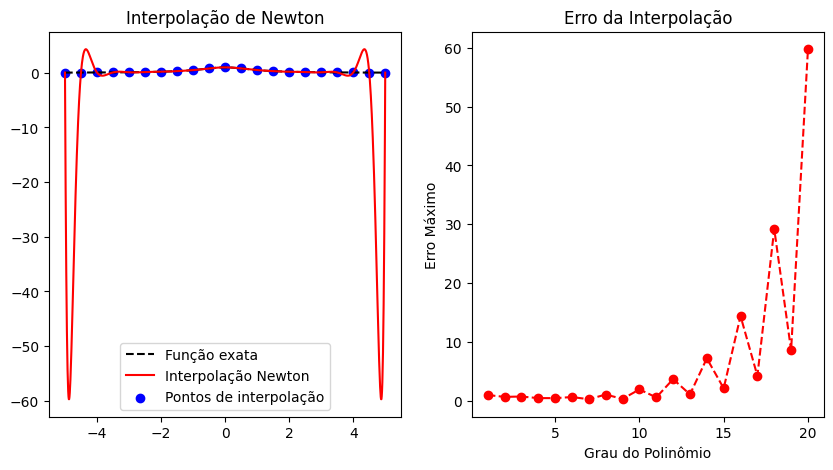

In [ ]:
#códigos
# Intervalo
a, b = -5, 5

# Função que queremos interpolar
def f(x):
    return 1/(x*x+1)

# Função para calcular a tabela de diferenças divididas
def calc_dif_div(xd, yd):
    n = len(xd)
    tabela = np.zeros((n, n))
    tabela[:, 0] = yd  # Primeira coluna são os valores de f(x)

    for j in range(1, n):
        for i in range(n - j):
            tabela[i, j] = (tabela[i+1, j-1] - tabela[i, j-1]) / (xd[i+j] - xd[i])

    return tabela[0]  # Retorna a primeira linha da tabela (os coeficientes)

# Função para avaliar o polinômio interpolador de Newton
def newton_interpolador(xd, coef, x):
    n = len(xd)
    resultado = coef[0]
    produto = 1
    for i in range(1, n):
        produto *= (x - xd[i-1])
        resultado += coef[i] * produto
    return resultado


# Pontos para avaliar a interpolação
N = 1000
x = np.linspace(a, b, N+1)
y_real = f(x)

# Testar diferentes graus
nmax = 20
erros = []

print("|    n | erro     ")
for n in range(1, nmax + 1):
    xd = np.linspace(a, b, n+1)  # Pontos de interpolação
    yd = f(xd)

    # Calcular os coeficientes das diferenças divididas
    f0n = calc_dif_div(xd, yd)

    # Avaliar o polinômio nos pontos de teste
    poln = np.array([newton_interpolador(xd, f0n, xj) for xj in x])

    # Calcular o erro máximo
    erro = np.max(np.abs(poln - y_real))
    erros.append(erro)

    print(f"| {n:4} | {erro:.8f} ")

    # Plotar o polinômio interpolador e o erro
plt.figure(figsize=(10, 5))

# Gráfico do polinômio interpolador
plt.subplot(1, 2, 1)
plt.plot(x, y_real, label="Função exata", color="black", linestyle="dashed")
plt.plot(x, poln, label="Interpolação Newton", color="red")
plt.scatter(xd, yd, color="blue", label="Pontos de interpolação")
plt.legend()
plt.title("Interpolação de Newton")

# Gráfico do erro
plt.subplot(1, 2, 2)
plt.plot(range(1, nmax + 1), erros, marker="o", linestyle="dashed", color="red")
plt.xlabel("Grau do Polinômio")
plt.ylabel("Erro Máximo")
plt.title("Erro da Interpolação")

plt.show()




---



---



## O problema de Runge

A função de Runge,
$$
    f(x) = \frac{1}{1 + x^2},\quad x \in [-5, 5],
$$
é infinitamente diferenciável (suave), mas suas derivadas tem características bem peculiares.

Sabemos que o erro de interpolação depende de derivadas da função, isto é, se $f\in \mathcal{C}^{n+1}([a,b])$, o polinômio interpolador $p_n \in \mathcal{P}_n$ de $f$ nos pontos $a\leq x_0 < x_1 < x_2 <...< x_n \leq b$ tem erro dado por

$$
f(x)-p_n(x)=\frac{f^{(n+1)}(\xi)}{(n+1)!}(x-x_0)(x-x_1)...(x-x_n)
$$
para $\xi \in [a,b]$.

Então vamos olhar para as derivadas da função de Runge.

In [ ]:
# Módulo do Python para symbolos
import sympy as sym
sym.init_printing()

#Simbolo
x = sym.symbols('x')

# Função e derivadas simbólicas
f = 1/(1+x**2)
df = sym.diff(f, x)
d2f = sym.diff(df, x)

# Visualização
display(sym.Eq(sym.symbols('f(x)'), f))
display(sym.Eq(sym.symbols('df(x)'), df))
display(sym.Eq(sym.symbols('d2f(x)'), d2f))


         1   
f(x) = ──────
        2    
       x  + 1

          -2⋅x   
df(x) = ─────────
                2
        ⎛ 2    ⎞ 
        ⎝x  + 1⎠ 

              2               
           8⋅x           2    
d2f(x) = ───────── - ─────────
                 3           2
         ⎛ 2    ⎞    ⎛ 2    ⎞ 
         ⎝x  + 1⎠    ⎝x  + 1⎠ 

Derivida de ordem n= 10


                 ⎛      10           8           6          4         2     ⎞
                 ⎜1024⋅y       2304⋅y      1792⋅y      560⋅y      60⋅y      ⎟
         3628800⋅⎜───────── - ───────── + ───────── - ───────── + ────── - 1⎟
                 ⎜        5           4           3           2    2        ⎟
                 ⎜⎛ 2    ⎞    ⎛ 2    ⎞    ⎛ 2    ⎞    ⎛ 2    ⎞    y  + 1    ⎟
                 ⎝⎝y  + 1⎠    ⎝y  + 1⎠    ⎝y  + 1⎠    ⎝y  + 1⎠              ⎠
dnf(y) = ────────────────────────────────────────────────────────────────────
                                              6                              
                                      ⎛ 2    ⎞                               
                                      ⎝y  + 1⎠                               

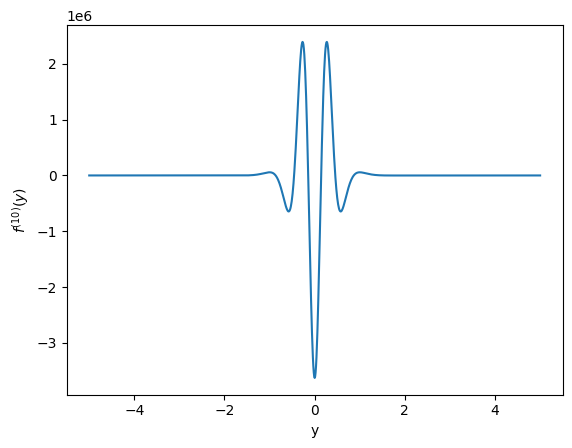


Máximo da derivada de ordem n =  3628800.0
Fatorial  de ordem n =  3628800


In [ ]:
#Derivada n-ésima de f
# Vamos trocar para y, para poder usar na fórmula do erro posteriormente
n=10
sym.init_printing()
y = sym.symbols('y')
f = 1/(1+y **2)
dnf = sym.diff(f, y, n)
print("Derivida de ordem n=", n)
display(sym.Eq(sym.symbols('dnf(y)'), dnf))

# Fazemos a função symbolica virar uma função de Python
lam_f = sym.lambdify(y, dnf, modules=['numpy'])

#Domínio e pontos de testagem
a = -5
b = 5
N = 1000
y_vals = np.linspace(a, b, N+1)
f_vals = lam_f(y_vals)

plt.plot(y_vals, f_vals)
plt.xlabel("y")
plt.ylabel("$f^{("+str(n)+")}(y)$")
plt.show()

print()
print("Máximo da derivada de ordem n = ", np.max(np.abs(f_vals)))
print("Fatorial  de ordem n = ", math.factorial(n))

**Conclusão**: A derivada cresce como um fatorial!

Da fórmula do erro
$$
E_n(x)=f(x)-p_n(x)=\frac{f^{(n+1)}(\xi)}{(n+1)!}(x-x_0)(x-x_1)...(x-x_n)
$$

ainda temos que analisar o produtório...vejamos a seguir:

Derivida de ordem n+1= 11



                       ⎛        10           8           6          4          ↪
                       ⎜   512⋅y       1280⋅y      1152⋅y      448⋅y      70⋅y ↪
           159667200⋅y⋅⎜- ───────── + ───────── - ───────── + ───────── - ──── ↪
                       ⎜          5           4           3           2    2   ↪
                       ⎜  ⎛ 2    ⎞    ⎛ 2    ⎞    ⎛ 2    ⎞    ⎛ 2    ⎞    y  + ↪
                       ⎝  ⎝y  + 1⎠    ⎝y  + 1⎠    ⎝y  + 1⎠    ⎝y  + 1⎠         ↪
dnp1f(y) = ─────────────────────────────────────────────────────────────────── ↪
                                                   7                           ↪
                                           ⎛ 2    ⎞                            ↪
                                           ⎝y  + 1⎠                            ↪

↪ 2     ⎞
↪       ⎟
↪ ── + 3⎟
↪       ⎟
↪  1    ⎟
↪       ⎠
↪ ───────
↪        
↪        
↪        

                                                                               ↪
                                                                               ↪
    4⋅x⋅y⋅(x - 5.0)⋅(x - 4.0)⋅(x - 3.0)⋅(x - 2.0)⋅(x - 1.0)⋅(x + 1.0)⋅(x + 2.0 ↪
                                                                               ↪
                                                                               ↪
                                                                               ↪
E = ────────────────────────────────────────────────────────────────────────── ↪
                                                                               ↪
                                                                               ↪
                                                                               ↪

↪                                 ⎛        10           8           6          ↪
↪                                 ⎜   512⋅y       1280⋅y      1152⋅y      448⋅ ↪
↪ )⋅(x + 3.0)⋅(x + 4.0)⋅(x 

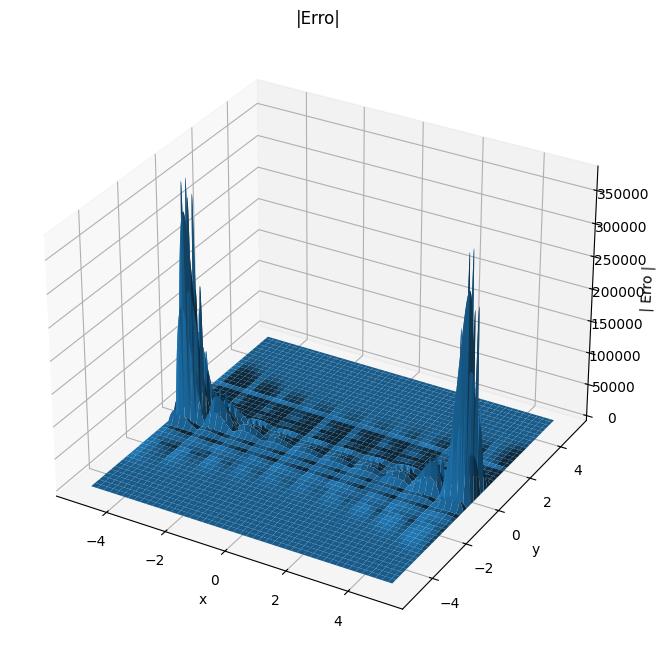

ValueError: x and y must have same first dimension, but have shapes (1,) and (1001,)

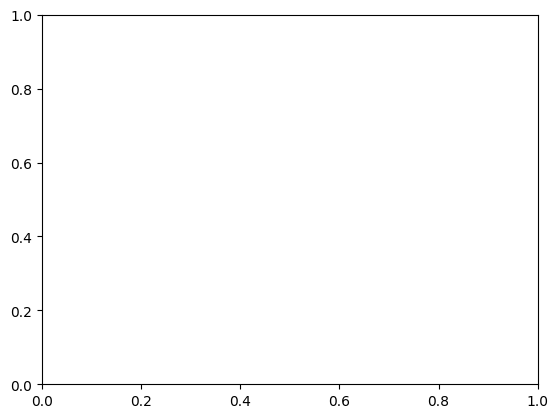

In [ ]:
#Grau do polinômio interpolador
n=10

#Pontos de interpolação
xd = np.linspace(a, b, n+1)

#Nossos simbolos
# y será o nosso \xi do teorema do erro
sym.init_printing()
x, y = sym.symbols('x y')

#A função
f = 1/(1+y **2)

#Derivada de ordem n+1
dnf = sym.diff(f, y, n+1)
print("Derivida de ordem n+1=", n+1)
print()
display(sym.Eq(sym.symbols('dnp1f(y)'), dnf))

# Divisão pelo fatorial
erro = dnf/sym.factorial(n+1)

#Produtorio
for xi in xd:
  erro = erro*(x-xi)
print()
display(sym.Eq(sym.symbols('E'), erro))
print()

lam_xy = sym.lambdify([x,y], erro, modules=['numpy'])

a = -5
b = 5
N = 1000
x = np.linspace(a, b, N+1)
y_vals = np.linspace(a, b, N+1)
X, Y = np.meshgrid(x, y_vals)
Z = lam_xy(X, Y)

#Gráfico 3D
fig = plt.figure(figsize=(14,8))
ax = plt.axes(projection='3d')
ax.plot_surface(X, Y, np.abs(Z))
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('| Erro |');
plt.title('|Erro|')
plt.show()

#Gráfico 2D
fx = np.empty(N+1)
#Vamos pegar o maior valor possível da derivada
for i, x in enumerate(x):
  fx[i] = np.max(np.abs(lam_xy(x, y_vals)))


plt.plot(x, fx)
plt.xlabel("x")
plt.ylabel("ErroMax")
plt.show()

print()
print("Máximo do Erro ", np.max(np.abs(fx)))

O erro cresce com o aumento do grau do polinômio, e não parece que conseguimos limitar o erro ao aumentar o n. Isso está de acordo com o que vimos no exercício 2!



---



## Pontos de Chebyshev de segunda espécie

Quando podemos escolher os pontos para interpolação, os resultados podem ser bem melhores. Uma classe boa é dada pelos pontos de Chebyshev de segunda espécie, que são os pontos extremos do polinômio de Chebyshev de grau $n$, contidos no intevalo $[-1,1]$. Eles são calculados pela expressão

$$
    x_i = -\cos\left(\frac{i\pi}{n}\right), \quad 0 \le i \le n.
$$

Note que estamos particionando um circulo em ângulos uniformemente iguais,
$$\theta_i=i\pi/n,$$ e em seguida estamos pegando os cossenos desses ângulos como os nossos pontos $x_i$.

Para termos uma ideia de como eles se distribuem no intervalo $[-1, 1]$, vejamos o caso $n=16$:


In [ ]:
#Número de pontos
n = 36

#Angulos uniformemente espaçados
theta = np.arange(n+1)*np.pi/n

#Pontos de Chebychev
x_cheby = -np.cos(theta)

#
figure, axes = plt.subplots(figsize=(13,9))

axes.add_artist(plt.Circle( (0.0, 0.0 ), 1.0 , fill = False , linewidth=0.4))

#plt.plot(np.cos(theta), np.sin(theta), color = 'green',linewidth=0.4)
zeros = np.zeros_like(theta)
plt.plot([zeros, np.cos(theta)], [zeros, np.sin(theta)], "--", color = "red", linewidth=0.2)
plt.plot([np.cos(theta), np.cos(theta)], [zeros, np.sin(theta)], color = "blue", linewidth=0.4)

plt.gca().set_aspect('equal')

plt.plot(x_cheby, np.zeros(n+1), 'o')
plt.show()

Note que os pontos são mais esparsos no meio e mais concentrados nos extremos do intervalo. Esta propriedade ajuda na interpolações de algumas funções, como a função de Runge. Em um intervalo $[a, b]$ arbitrário, transportamos esses pontos usando a transformação linear afim que leva $[-1,1]$ em $[a, b]$:

$$
    x_i = -0.5\cdot(b-a)\cdot\cos\left(\frac{i\pi}{n}\right) + 0.5\cdot(a+b), \quad 0 \le i \le n.
$$




Vejamos o nosso exemplo de interpolação da função $2^x$.

In [ ]:
# Nossa tabela

a = -1  #inicio
b = 2   #fim
n = 3   #grau (são n+1 pontos)

#Valores de x como pontos de chebychev
xd = -0.5*(b-a)*np.cos(np.arange(n+1)*np.pi/n)+0.5*(a+b)
print("x:", xd)

# A função que queremos interpolar
def f(x):
  return np.power(2.0, x)

#Valores de 2^x nos pontos de interpolação
yd = f(xd)
print("y:", yd)

#Pontos de testagem
N = 1000
x = np.linspace(a, b, N)

#Função exata
y_real = f(x)

#Avalio o polinomio em cada um desses pontos
poln=np.empty(N)
for j, xj in enumerate(x):
  poln[j] = pol(xj, xd, yd)

#Gráficos
print("Função e polinômio interpolador:")
plt.plot(x, poln, label="Pol Interp", linewidth=1)
plt.plot(x, y_real, label="Func Exata",linewidth=1)
plt.plot(xd, yd, 'g.', label="dados")
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
plt.legend()
plt.show()

print("Erro:")
plt.plot(x, poln-y_real, label="Erro", linewidth=1)
plt.plot(xd, np.zeros(len(xd)), 'g.', label="dados")
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
plt.legend()
plt.show()

print("Erro máximo = ", np.max(np.abs(poln-y_real)) )

E se variamos o grau dos polinômios?


In [ ]:
a = -1  #inicio
b = 2   #fim

def f(x):
  return np.power(2.0, x)

#Pontos de testagem
N = 1000
x = np.linspace(a, b, N)
#Função exata
y_real = f(x)

#Varrer diferentes graus
nmax = 20
print("|    n | erro     ")
for n in range(1, nmax):
  #Valores de x como pontos de chebychev
  xd = -0.5*(b-a)*np.cos(np.arange(n+1)*np.pi/n)+0.5*(a+b)
  yd = f(xd)                  #y tabelado
  poln=np.empty(N) #Avalio o polinomio nos pontos
  for j, xj in enumerate(x):
    poln[j] = pol(xj, xd, yd)

  erro = np.max(np.abs(poln-y_real))
  print(f"| {n:4} | {erro:0.8} ")


Será que ficou melhor ou pior que o caso uniformemente espaçado?

Como ficam as aproximações para a função do exemplo de Runge usando estes pontos no intervalo $[-5,5]$?



---



---



### ❗Exercício 3 ❗



Considere a função
$$
    f(x) = \frac{1}{1 + x^2},\quad x \in [-5, 5].
$$

e os  $n+1$ pontos de Chebychev de segunda espécia intervalos, onde $n$ é último dígito não nulo do seu número USP ($n=$ magic_int). Isto é, os pontos são
$$
    x_i = -0.5\cdot(b-a)\cdot\cos\left(\frac{i\pi}{n}\right) + 0.5\cdot(a+b), \quad 0 \le i \le n.
$$
considerando $a=-5$, $b=5$.


1.  Construa o polinômio interpolador dessa função nesses pontos.
2.  Avalie esse polinômio em $N=100$ pontos e faça um gráfico da aproximação e do erro.
3.  Calcule o erro máximo
4.  Varie o valor de $n$ e verifique se o erro cai quando aumentamos o grau do polinômio. Faça uma tabela do erro em função de $n$.

|    n | erro     
|    1 | 0.82891247 
|    2 | 0.82891247 
|    3 | 0.82891247 
|    4 | 0.82891247 
|    5 | 0.82891247 
|    6 | 0.82891247 
|    7 | 0.82891247 
|    8 | 0.82891247 
|    9 | 0.82891247 
|   10 | 0.82891247 
|   11 | 0.82891247 
|   12 | 0.82891247 
|   13 | 0.82891247 
|   14 | 0.82891247 
|   15 | 0.82891247 
|   16 | 0.82891247 
|   17 | 0.82891247 
|   18 | 0.82891247 
|   19 | 0.82891247 
|   20 | 0.82891247 


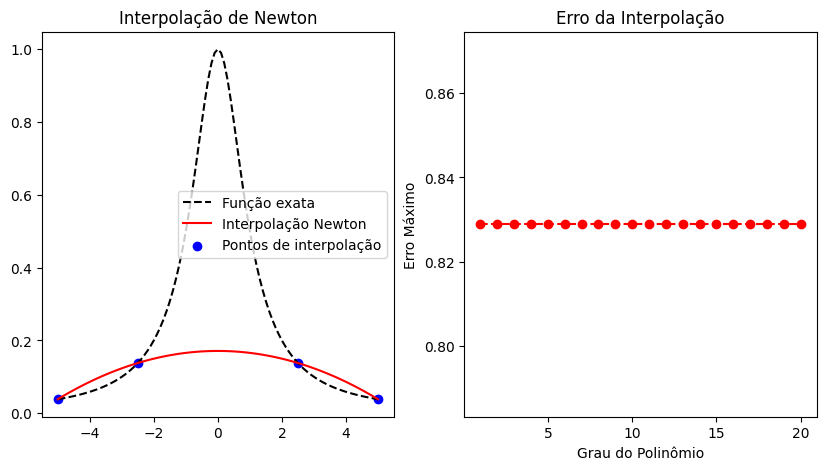

In [ ]:
n = magic_int
a,b =-5, 5
xi = -0.5*(b-a)*np.cos(np.arange(magic_int+1)*np.pi/magic_int) + 0.5*(a + b)  # Pontos de interpolação novos
def h(x):
  return 1/(1+x*x)

yd = h(xi)    #yd novo
# Pontos para avaliar a interpolação
N = 100
x = np.linspace(a, b, N+1)
y_real = h(x)
# Testar diferentes graus
nmax = 20
erros = []

print("|    n | erro     ")
for n in range(1, nmax + 1):
  #xd = np.linspace(a, b, n+1)  # Pontos de interpolação
  #yd = f(xd)
  # Calcular os coeficientes das diferenças divididas
  f0n = calc_dif_div(xi, yd)

  # Avaliar o polinômio nos pontos de teste
  poln = np.array([newton_interpolador(xi, f0n, xj) for xj in x])

  # Calcular o erro máximo
  erro = np.max(np.abs(poln - y_real))
  erros.append(erro)

  print(f"| {n:4} | {erro:.8f} ")

# Plotar o polinômio interpolador e o erro
plt.figure(figsize=(10, 5))

# Gráfico do polinômio interpolador
plt.subplot(1, 2, 1)
plt.plot(x, y_real, label="Função exata", color="black", linestyle="dashed")
plt.plot(x, poln, label="Interpolação Newton", color="red")
plt.scatter(xi, yd, color="blue", label="Pontos de interpolação")
plt.legend()
plt.title("Interpolação de Newton")

# Gráfico do erro
plt.subplot(1, 2, 2)
plt.plot(range(1, nmax + 1), erros, marker="o", linestyle="dashed", color="red")
plt.xlabel("Grau do Polinômio")
plt.ylabel("Erro Máximo")
plt.title("Erro da Interpolação")

plt.show()



---



## Interpolação em Numpy/Scipy

Vejamos algumas funções que ajudam a fazermos interpolações em Python usando Scipy.

In [ ]:
#SCIPY
from scipy import interpolate

#Nossa tabela
a = -1  #inicio
b = 2   #fim
n = 3   #grau (são n+1 pontos)

#Valores de x uniformemente espaçados
xd = np.linspace(a, b, n+1)

#Valores de x como pontos de chebychev
#xd = -0.5*(b-a)*np.cos(np.arange(n+1)*np.pi/n)+0.5*(a+b)
print("x:", xd)

# A função que queremos interpolar
def f(x):
  return np.power(2.0, x)

#Valores de 2^x nos pontos de interpolação
yd = f(xd)
print("y:", yd)

#Interpolação SCIPY - Retorna uma função!!!
pol_interp = interpolate.interp1d(xd, yd, kind='cubic')

raiz2_aprox = pol_interp(0.5)
raiz2_np = np.sqrt(2.0)
print()
print("Raiz de 2 aproximada : " , raiz2_aprox)
print("Raiz de 2 do numpy : " , raiz2_np)
print("Erro:", raiz2_aprox - raiz2_np )


Será que bateu com a nossa implementação inicial?


O Scipy interpolate não faz interpolação de altos graus como a nossa implementação 😞
  
  .... mas faz splines! 😀

## Splines

Uma alternativa a usar pontos de Chebychev seria usar splines. Vamos começar usando splines lineares.

Dados os pontos $x_i$, $i=0,1,...n$, os splines lineares são simplesmente interpolações lineares em cada sub-intervalo $[x_i, x_{i+1}]$.

Vamos usar a função do Scipy, por simplicidade, no exemplo a seguir.

In [ ]:
#SCIPY

#Nossa tabela
a = -1  #inicio
b = 2   #fim
n = 3   #Pontos usados (agora não é mais o grau!!!!)

#Valores de x uniformemente espaçados
xd = np.linspace(a, b, n+1)
print("x:", xd)

# A função que queremos interpolar
def f(x):
  return np.power(2.0, x)

#Valores de 2^x nos pontos de interpolação
yd = f(xd)
print("y:", yd)

#Interpolação - Retorna uma função!!! Splines lineares
pol_interp = interpolate.interp1d(xd, yd, kind='linear')

raiz2_aprox = pol_interp(0.5)
raiz2_np = np.sqrt(2.0)
print()
print("Raiz de 2 aproximada : " , raiz2_aprox)
print("Raiz de 2 do numpy : " , raiz2_np)
print("Erro:", raiz2_aprox - raiz2_np )

O que acontece quando aumentamos o número de pontos na interpolação linear por pedaços?

In [ ]:
# Nossa tabela
a = -1  #inicio
b = 2   #fim
n = 4   #grau (são n+1 pontos)
print(n)

#Pontos igualmente espaçados
xd =  np.linspace(a, b, n+1)
print("x:", xd)

# A função que queremos interpolar
def f(x):
  return np.power(2.0, x)

#Valores da função nos pontos de interpolação
yd = f(xd)
print("y:", yd)

#Pontos de testagem
N = 1000
x = np.linspace(a, b, N)

#Função exata
y_real = f(x)

#Avalio o polinomio (spline) em cada um desses pontos
pol_interp = interpolate.interp1d(xd, yd, kind='linear')
#Avalio o polinomio nos pontos
poln=pol_interp(x)


print("Função e polinômio interpolador:")
plt.plot(x, poln, label="Pol Interp", linewidth=1)
plt.plot(x, y_real, label="Func Exata",linewidth=1)
plt.ply_realyd, 'g.', label="dados")
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
plt.legend()
plt.show()

print("Erro:")
plt.plot(x, poln-y_real, label="Erro", linewidth=1)
plt.plot(xd, np.zeros(len(xd)), 'g.', label="dados")
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
plt.legend()
plt.show()

print("Erro máximo = ", np.max(np.abs(poln-y_real)) )

In [ ]:

a = -1  #inicio
b = 2   #fim

def f(x):
  return np.power(2.0, x)

#Pontos de testagem
N = 1000
x = np.linspace(a, b, N)
#Função exata
y_real= f(x)

#Varrer diferentes quantidades de pontos de interpolação
nmax = 40
print("|    n | erro     ")
for n in range(1, nmax):
  xd = np.linspace(a, b, n+1) #x tabelado
  yd = f(xd)                  #y tabelado
  #Monto o polinômio linear por pedaços
  pol_interp = interpolate.interp1d(xd, yd, kind='linear')
  #Avalio o polinomio nos pontos
  poln=pol_interp(x)

  erro = np.max(np.abs(poln-y_real))
  print(f"| {n:4} | {erro:0.8} ")

### ❗Exercício 4 ❗



Considere a função
$$
    f(x) = \frac{1}{1 + x^2},\quad x \in [-5, 5].
$$

e os pontos uniformemente espaçados em $n$ intervalos, onde é último dígito não nulo do seu número USP ($n=$ magic_int). Ou seja,
$$
x_i = 10 i /n -5, \quad, i=0,1,...,n
$$

1.  Construa o spline linear  dessa função nesses pontos usando o Scipy Interpolate.
2.  Avalie esse polinômio em $N=1000$ pontos uniformemente espaçados e compute o erro máximo obtido.

**Responda:**
*  O erro cai ao aumentar o número de pontos de interpolação ($n$)?
*   Ao duplicarmos o número de pontos, por quanto o erro cai, aproximadamente?
*  Estime, variando o valor de $n$, qual seria o valor de $n$ necessário para termos um erro menor que $10^{-2}$.


In [ ]:
#códigos
#alterar a funcao para funcionar com a nova funcao
def erro_Max_spline(x_pontos, y_pontos, N=1000):
    x = np.linspace(-5, 5, N)
    y_rouge = g(x)  # Função g(x)

    # Interpolação usando spline linear
    spline = interpolate.interp1d(x_pontos, y_pontos, kind='linear')
    y_spline = spline(x)

    erro_spline = np.abs(y_rouge - y_spline)

    # Gráficos
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.plot(x, y_rouge, label=r'$f(x) = \frac{1}{1 + x^2}$', color='orange')
    plt.plot(x, y_spline, label='Spline Linear', linestyle='--', color='blue')
    plt.scatter(x_pontos, y_pontos, color='purple', label='Pontos de Interpolação')
    plt.legend()
    plt.title('Spline Linear')

    plt.subplot(1, 2, 2)
    plt.plot(x, erro_spline, label='Erro do Spline', color='red')
    plt.title('Erro da Interpolação com Spline')
    plt.legend()

    plt.show()
    return max(erro_spline)


def g(x):
  return 1/(1+x**2)

i = np.arange(magic_int + 1)
x_pontos = (10 * i / magic_int) - 5
y_pontos = g(x_pontos)

erro_max = erro_Max_spline(x_pontos, y_pontos)

print("Erro máximo por Spline: ",erro_max)


In [ ]:





#Pontos de testagem
N = 1000
x = np.linspace(a, b, N)
#Função exata
y_real = g(x)

#O erro cai ao aumentar o número de pontos de interpolação ( n )?
nmax = 20
print("|    n | erro     ")
for n in range(1, nmax):
  i = np.arange(n + 1)
  xd = (10 * i / n) - 5
  yd = g(xd)
  pol_interp = interpolate.interp1d(xd, yd, kind='linear')
  poln=pol_interp(x)
  erro = np.max(np.abs(poln-y_real))
  print(f"| {n:4} | {erro:0.8} ")
#Como visto epla tabela impressa sim o erro cai ao aumentar n

#Ao duplicarmos o número de pontos, por quanto o erro cai, aproximadamente?
print("Redução do erro com dobro de pontos: ", 1-erro/erro_max)

n= 1
#Estime, variando o valor de  n , qual seria o valor de  n  necessário para termos um erro menor que  10−2 .

while erro>=0.01:
  i = np.arange(n + 1)
  xd = (10 * i / n) - 5
  yd = g(xd)
  pol_interp = interpolate.interp1d(xd, yd, kind='linear')
  poln=pol_interp(x)
  erro = np.max(np.abs(poln-y_real))
  n+=1

print("n igual a = ", n,"erro(n) =", erro)


|    n | erro     
|    1 | 0.96151341 
|    2 | 0.41813687 
|    3 | 0.73526907 
|    4 | 0.18023038 
|    5 | 0.49997495 
|    6 | 0.062303389 
|    7 | 0.33781279 
|    8 | 0.063901283 
|    9 | 0.23582401 
|   10 | 0.067442196 
|   11 | 0.17120783 
|   12 | 0.065041967 
|   13 | 0.12884093 
|   14 | 0.059758897 
|   15 | 0.099974951 
|   16 | 0.053551746 
|   17 | 0.079592785 
|   18 | 0.047429875 
|   19 | 0.06474179 
Redução do erro com dobro de pontos:  0.9119481660106135
n igual a =  51 erro(n) = 0.009325485529674937




---


Para melhorar a velocidade de convergência, podemos usar splines cúbicos.

**O que são splines cúbicos?**

São funções interpoladoras (passam nos pontos de interesse) constituídas por cúbicas em cada sub-intervalo $[x_i, x_{i+1}]$. Esses polinômios cúbicos são definidos pata que nos pontos de interpolação concordem em suas derivadas primeiras e segundas, gerando, portanto, uma função interpoladora suave.

Veja mais informações no livro texto da disciplina (Burden & Faires). Ainda em:
*   https://www.ime.usp.br/mat/2458/textos/splines.pdf
*   https://en.wikiversity.org/wiki/Cubic_Spline_Interpolation



### 🧩 Exercício 5 🧩



Considere a função
$$
    f(x) = \frac{1}{1 + x^2},\quad x \in [-5, 5].
$$

e os pontos uniformemente espaçados em $n$ intervalos, onde é último dígito não nulo do seu número USP ($n=$ magic_int). Ou seja,
$$
x_i = 10 i /n -5, \quad, i=0,1,...,n
$$

1.  Construa o spline **cúbico**  dessa função nesses pontos usando o Scipy Interpolate. (Pode usar a função scipy.interpolate.CubicSpline)
2.  Avalie esse polinômio em $N=1000$ pontos uniformemente espaçados e compute o erro máximo obtido.

**Responda:**
*  O erro cai ao aumentar para um número de pontos de interpolação maior?
*   Ao duplicarmos o número de pontos, por quanto o erro cai, aproximadamente?
*  Estime, variando o valor de $n$, qual seria o valor de $n$ necessário para termos um erro menor que $10^{-2}$.




---



---



## 🧩 Fórmula baricêntrica 🧩

In [ ]:
from scipy.special import binom # Coeficientes binomiais

Vejamos uma outra forma de implementar a interpolação de Langrange, que pode facilitar a vetorização e o uso de pontos arbitrários, evitando recálculos que aparecem na fórmula de Lagrange.

**Referência:** Algoritmos para interpolação lagrangeana baricêntrica, conforme descrito em Berrut & Trfethen, *Barycentric Lagrange Interpolation*, SIAM Review 46(3) (2004), pp. 501--517

https://people.maths.ox.ac.uk/trefethen/barycentric.pdf

Vimos que o polinômio interpolador $p_n$ da tabela na forma de Lagrange é dado por

$$
    p_n(x) = \sum_{j=0}^n y_j L_j(x)
$$

onde os polinômios de Lagrange $L_j$ são definidos por

$$
    L_j(x) = \prod^n_{\substack{k = 0 \\ k \ne j}} \frac{x - x_k}{x_j - x_k}, \quad 0 \le j \le n.
$$

Manipulando-se as fórmulas acima podemos escrever a fórmula de Lagrange modificada

$$
    p_n(x) = L(x) \sum_{j=0}^n \frac{\omega_j}{x - x_j}y_j, \quad x \ne x_i,\ 0 \le i \le n,
$$

onde

$$
L(x) = (x - x_0)(x - x_1) \dots (x - x_n)
$$

e os **pesos baricêntricos** $\omega_j$ são definidos como

$$
    \omega_j = \Bigg[\prod^n_{\substack{k=0 \\ k \ne j}}(x_j - x_k)\Bigg]^{-1}, \quad 0 \le j \le n .
$$

Sabendo-se que se $y_i = 1$, $0 \le i \le n$, então $p_n(x) = 1$, $\forall x \in \mathbb{R}$, obtemos

$$
    1 = L(x)\sum_{j=0}^n \frac{\omega_j}{x - x_j}, \quad \forall x \ne x_i,\ 0 \le i \le n,
$$

então podemos dividir a expressão do nosso $p_n$ por este "1" e cancelar o termo $L(x)$ para obter a **fórmula baricêntrica:**

$$
    p_n(x) = \frac{\sum_{j=0}^n\frac{\omega_j}{x - x_j}y_j}{\sum_{m=0}^n\frac{\omega_m}{x - x_m}},
    \quad x \ne x_i,\ 0 \le i \le n.
$$

Se $x=x_j$, devemos simplesmente devolver que $p(x_j)=y_j$.

Há casos específicos nos quais os pesos são conhecidos explicitamente. Entre eles:

> **1)** Pontos igualmente espaçados no intervalo $[a,b]$
\begin{align}
    x_i &= a + i\cdot\left(\frac{b-a}{n}\right), \quad 0 \le i \le n,\\
    \omega_j &= (-1)^j \cdot \binom{n}{j}, \quad 0 \le j \le n.
\end{align}

> **2)** Pontos de Chebyshev do segundo tipo no intervalo $[a, b]$:
\begin{align}
    x_i &= -\frac{b-a}{2} \cdot \cos\left(\frac{i\pi}{n}\right),\quad 0 \le i \le n,\\
    \omega_j &= (-1)^j \cdot d_j,\ 0 \le j \le n, \text{ com } d_0 = d_n = 0.5,\ d_j = 1,\ 1 \le j \le n-1.
\end{align}

Note que nos dois casos os pesos independem do intervalo $[a,b]$. A diferença em cada intervalo seria um fator de escala comum a todos os pesos, o que não muda o resultado da fórmula baricêntrica.



Vejamos isso na prática, agora com uma implementação vetorial mais eficiente usando a fórmula baricêntrica:

In [ ]:
# Cálculo dos pesos da fórmula baricêntrica (w_j)

#Caso geral (para conjuntos arbitrários de pontos)
def w_bary(xd):
    # Cálculo dos pesos para a interpolação Lagrangeana baricêntrica.
    # Há duas rotinas separadas para os casos de pontos igualmente
    # espaçados e pontos de Chebyshev de segunda espécies. Ambos dependem
    # apenas da quantidade de pontos.

    np1 = np.size(xd) # n + 1

    # espaçamento arbitrário; use a fórmula
    v = np.empty(np1)
    for j in range(np1):
        aux = xd[j] - xd
        mask = (aux != 0.)
        v[j] = np.prod(aux[mask])
    return 1.0/v

#Caso de pontos equidistantes (só depende do número de pontos)
def w_equi(npoints): # npoints pontos equidistantes (npoints = n+1)
    vrange = np.arange(npoints) # [0, 1, ..., n]
    return np.power(-1, vrange) * binom(npoints-1, vrange) # (-1)^j * binom(n,j), j de 0 a n

#Caso dos pontos de Chebyshev de segunda espécies (só depende do número de pontos).
def w_cheby2(npoints): # np pontos de Chebyshev do segundo tipo
    vrange = np.arange(npoints) # [0, 1, ..., n]
    d = np.ones(npoints - 2); d = np.insert(d, 0, 0.5); d = np.append(d, 0.5) # [0.5,1,...,1,0.5]
    return np.power(-1, vrange) * d # [0.5,-1,...,(-1)^(n-1),(-1)^n * 0.5]

In [ ]:
def pol_bary(x, xd, yd, w):
    # Cálculo do valor no ponto x do polinômio interpolador
    # da tabela (xd, yd) usando a fórmula baricêntrica,
    # onde os pesos w relativos aos pontos xd foram
    # previamente calculados.
    #
    # A rotina vai devolver y=pol_bary(x) com as avaliações do polinômio nos pontos x

    np1 = np.size(xd) # n + 1
    N = np.size(x) # pontos de amostragem (funciona para escalares e vetores)
    if N == 1:     #Caso a entrada seja um escalar, e não um vetor
      x = np.array([x])
    numer = np.zeros(N) #numerador
    denom = np.zeros(N) #denominador
    y = np.zeros(N) #denominador
    val = np.zeros(N) #denominador

    #A formula baricentrica só vale para pontos x diferentes dos xd tabelados
    #  nos pontos tabelados devolvemos o valor de yd
    for j in range(np1):
      #Se o ponto de amostragem coincidir com um ponto tabelado
      xtab = (x - xd[j] == 0 )
      #Guardo já a resposta tabelada de yj
      y[xtab] = yd[j]
      #Precisamos tirar esse ponto da nossa lista de amostras, para evitar divisões por zero
      val[xtab] = np.nan

    #Indices válidos (que não são nan)
    i_val = ~np.isnan(val)

    xdiff = np.zeros_like(y)
    numer = np.zeros_like(y)
    denom = np.zeros_like(y)
    tmp = np.zeros_like(y)

    for j in range(np1):
        xdiff[i_val] = x[i_val] - xd[j]    #Diferença dos pontos x amostrados e dos tabelados
        tmp[i_val] = w[j] / xdiff[i_val]   # não teremos divisão por zero, pois trabalhamos apenas com x diferente de xd
        numer[i_val] += tmp[i_val] * yd[j] # numerador
        denom[i_val] += tmp[i_val]         # denominador

    y[i_val] = numer[i_val] / denom[i_val]

    if (N > 1):
        return y # retorna um array
    else:
        return y[0] # retorna um escalar

**Exemplo**
Considere a tabela

$$
    \begin{array}{c|rccc}
        x & -1 & 0 & 1 & 2 \\
        \hline
        2^x & 0.5 & 1 & 2 & 4
    \end{array}
$$

da função $2^x$ nos pontos $-1, 0, 1$ e $2$. Primeiramente, calculemos os pesos baricêntricos. Podemos usar a expressão para pontos igualmente espaçados:


In [ ]:
# Nossa tabela

a = -1  #inicio
b = 2   #fim
n = 3   #grau (são n+1 pontos)

#Valores de x
xd = np.linspace(a, b, n+1)
print("x:", xd)

# A função que queremos interpolar
def f(x):
  return np.power(2.0, x)

#Valores de 2^x nos pontos de interpolação
yd = f(xd)
print("y:", yd)

w = w_equi(np.size(xd))
print("w:", w)

Que valores obteríamos se usássemos a fórmula para espaçamento arbitrário?


In [ ]:
w_arb = w_bary(xd)
print(w_arb)

Note que o resultado é $1/6$ vezes o resultado obtido usando a expressão para pontos igualmente espaçados. Mas será que isso importa?




Calculemos uma aproximação para $\sqrt{2}$ usando a fórmula baricêntrica, com as duas expressões para os pesos:


In [ ]:
raiz2_equi = pol_bary(0.5, xd, yd, w)
raiz2_arb = pol_bary(0.5, xd, yd, w_arb)
print("raiz2_equi= ", raiz2_equi)
print("raiz2_arb= ", raiz2_arb)

O resultado é o mesmo (módulo arredondamento).

Vejamos o gráfico do polinômio interpolador, juntamente com os dados (usando os pesos da expressão para pontos igualmente espaçados) e o gráfico da função:


In [ ]:
N = 1000
x = np.linspace(a, b, N)

#Função exata
y_real= f(x)

w = w_equi(np.size(xd))
#w = w_bary(xd)

#Avalio o polinomio em cada um desses pontos
# usando a fórmula baricêntrica de forma vetorial
poln=pol_bary(x, xd, yd, w)

print("Função e polinômio interpolador:")
plt.plot(x, poln, label="Pol Interp", linewidth=1)
plt.plot(x, y_real, label="Func Exata",linewidth=1)
plt.plot(xd, yd, 'g.', label="dados")
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
plt.legend()
plt.show()

print("Erro:")
plt.plot(x, poln-y_real, label="Erro", linewidth=1)
plt.plot(xd, np.zeros(len(xd)), 'g.', label="dados")
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
plt.legend()
plt.show()

print("Erro máximo = ", np.max(np.abs(poln-y_real)) )



---



O polinômio interpolador não depende da ordem dos pontos $(x_i, y_i)$, $0 \le i \le n$. Calculemos então os pesos para a tabela dada na forma

$$
    \begin{array}{c|rccc}
        x & 1 & -1 & 2 & 0 \\
        \hline
        2^x & 2 & 0.5 & 4 & 1
    \end{array}
$$

e comparemos o valor obtido para o polinômio nos pontos usados para gerar o gráfico com os valores anteriores.


In [ ]:
xdd = np.array([1., -1., 2., 0.])
ydd = np.power(2., xdd)
print("x= ", xdd)
print("y= ", ydd)

In [ ]:
ww = w_bary(xdd) # Temos que usar espaçamento arbitrário !!!
print("pesos= ", ww)

In [ ]:
yy = pol_bary(x, xdd, ydd, ww)



Os resultados, dentro da precisão, são os mesmos?


In [ ]:
erro_rel = np.max(np.abs((yy-poln)))
print("erro máximo: {:.1e}".format(erro_rel))

A aproximação parece razoável em todo o intervalo (nem sempre é assim). Vejamos como o erro se comporta quando mudamos o grau do polinômio.


In [ ]:
a = -1  #inicio
b = 2   #fim
nmax = 20
def f(x):
  return np.power(2.0, x)

#Pontos de testagem
N = 100
x = np.linspace(a, b, N)
#Função exata
y_real= f(x)

#Varrer diferentes graus
for n in range(nmax):
  xd = np.linspace(a, b, n+1) #x tabelado
  yd = f(xd)                  #y tabelado
  w = w_equi(np.size(xd))     #pesos baricêntricos
  poln = pol_bary(x, xd, yd, w) #Avalio o polinomio nos pontos
  erro = np.max(np.abs(poln-y_real))
  print(n, erro)



---



---



**Exemplo de Runge**

O exemplo de Runge é um exemplo clássico para ilustrar a não convergência do polinômio interpolador para a função quando aumentamos a quantidade de *pontos igualmente espaçados*. A função e o intervalo escolhido são:

$$
    f(x) = \frac{1}{1 + x^2},\quad x \in [-5, 5].
$$

Iremos observar o comportamento do polinômio interpolador para alguns conjuntos de pontos igualmente espaçados no intervalo $[-5,5]$.


In [ ]:
a = -5  #inicio
b = 5   #fim
def f(x):
  return 1.0/(1.0 + x*x) # Função


In [ ]:
#Função que interpola a função f(x) usando n+1 pontos uniformemente espaçados
#   por um polinômio de grau n e avalia em N pontos fazendo gráfico da função original e do polinômio
def interpol_equi_plot(n, N, a, b):
  np1 = n+1 # n + 1
  xd = np.linspace(a, b, np1)
  yd = f(xd)
  w = w_equi(np1)
  x = np.linspace(a, b, N) # Pontos para gerar gráficos
  fx = f(x) # Valor da função nesses pontos
  y = pol_bary(x, xd, yd, w)

  plt.plot(x, fx, label="f(x)")
  plt.plot(x, y, label="Pol Grau n ="+str(n))
  plt.plot(xd, yd,  'go', label="tabela")
  plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left");



In [ ]:
grau_pol = 10
interpol_equi_plot(grau_pol, 1000, -5, 5)


Vamos variar o grau e ver o que acontece com o erro.

In [ ]:
nmax = 30
erros = np.zeros(nmax)
N = 1000
print("Grau   Erro")
for n in range(nmax):
  np1 = n+1 # n + 1
  xd = np.linspace(a, b, np1)
  yd = f(xd)
  w = w_equi(np1)
  x = np.linspace(a, b, N) # Pontos para gerar gráficos
  fx = f(x) # Valor da função nesses pontos
  y = pol_bary(x, xd, yd, w)
  erros[n] = np.max(np.abs(y-fx))
  print(n, erros[n])


Pode-se demonstrar rigorosamente que os polinômios interpoladores aproximam a função em um intervalo em torno da origem e divergem fora dele. As figuras acima dão uma ideia do que ocorre.


Vejamos agora se usarmos os pontos de Chebychev.




In [ ]:
#Função que interpola a função f(x) usando n+1 pontos espaçados nos pontos de Chebychev
#   por um polinômio de grau n e avalia em N pontos fazendo gráfico da função original e do polinômio
def interpol_cheby_plot(n, N, a, b):
  np1 = n+1 # n + 1

  #Pontos de Chebychev
  xd = -0.5*(b-a)*np.cos(np.arange(n+1)*np.pi/n)
  #Valores de f nos pontos de Chebychev
  yd = f(xd)
  #Pesos de Chebychev
  w = w_cheby2(np1)

  #Testagem
  x = np.linspace(a, b, N) # Pontos para gerar gráficos
  fx = f(x) # Valor da função nesses pontos
  y = pol_bary(x, xd, yd, w) #Avaliação do polinômio

  #Gráficos
  plt.plot(x, fx, label="f(x)")
  plt.plot(x, y, label="Pol Grau n ="+str(n))
  plt.plot(xd, yd,  'go', label="tabela")
  plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left");

  #Erro
  print("erro:", np.max(np.abs(y-fx)))

In [ ]:
grau_pol = 20
interpol_cheby_plot(grau_pol, 1000, -5, 5)



Vejamos como se comporta o erro ao aumentarmos o grau do polinômio.


In [ ]:
nmax = 30
erros = np.zeros(nmax)
N = 1000
print("Grau   Erro")
for n in range(2, nmax):
  np1 = n+1 # n + 1

  #Pontos de Chebychev
  xd = -0.5*(b-a)*np.cos(np.arange(n+1)*np.pi/n)

  #Valores de f nos pontos escolhidos
  yd = f(xd)

  #Pesos de Chebychev
  w = w_cheby2(np1)

  x = np.linspace(a, b, N)  #Pontos de testagem
  fx = f(x) # Valor da função nesses pontos
  y = pol_bary(x, xd, yd, w)

  erros[n] = np.max(np.abs(y-fx))
  print(n, erros[n])




---



---



Um teste curioso: Vamos usar os pontos uniformemente espaçados, mas os pesos de Chebychev.



In [ ]:
#Função que interpola a função f(x) usando n+1 pontos espaçados nos pontos de Chebychev
#   por um polinômio de grau n e avalia em N pontos fazendo gráfico da função original e do polinômio
def interpol_equi_cheby_plot(n, N, a, b):
  np1 = n+1 # n + 1

  #Pontos de Chebychev
  #xd = -0.5*(b-a)*np.cos(np.arange(n+1)*np.pi/n)
  #Pontos uniformemente espaçados
  xd = np.linspace(a, b, np1)

  #Valores de f nos pontos de unif espaçados
  yd = f(xd)

  #Pesos de Chebychev
  w = w_cheby2(np1)

  #Testagem
  x = np.linspace(a, b, N) # Pontos para gerar gráficos
  fx = f(x) # Valor da função nesses pontos
  y = pol_bary(x, xd, yd, w) #Avaliação do polinômio

  #Gráficos
  plt.plot(x, fx, label="f(x)")
  plt.plot(x, y, label="Pol Grau n ="+str(n))
  plt.plot(xd, yd,  'go', label="tabela")
  plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left");

  #Erro
  print("erro:", np.max(np.abs(y-fx)))

In [ ]:
grau_pol = 10
interpol_equi_cheby_plot(grau_pol, 1000, -5, 5)

In [ ]:
nmax = 50
erros = np.zeros(nmax)
N = 1000
print("Grau   Erro")
for n in range(2, nmax):
  np1 = n+1 # n + 1

  #Pontos de Chebychev
  #xd = -0.5*(b-a)*np.cos(np.arange(n+1)*np.pi/n)
  #Pontos uniformemente espaçados
  xd = np.linspace(a, b, np1)
  #Valores de f nos pontos escolhidos
  yd = f(xd)
  #Pesos de Chebychev
  w = w_cheby2(np1)


  x = np.linspace(a, b, N)  #Pontos de testagem
  fx = f(x) # Valor da função nesses pontos
  y = pol_bary(x, xd, yd, w)
  erros[n] = np.max(np.abs(y-fx))
  print(n, erros[n])

Nesse caso também temos convergência! Mas note que a função que interpolação que estamos montando não é mais um polinômio! Mas sim uma função racional.

Mais intormações em https://link.springer.com/article/10.1007/s00211-007-0093-y



---



---

